In [36]:
import pandas as pd
from pathlib import Path

base = Path('.')
path_test = base / 'test_processed.csv'
path_agg  = base / '聚合特征增强版数据集.csv'

test_df = pd.read_csv(path_test, encoding='utf-8-sig')
agg_df  = pd.read_csv(path_agg, encoding='utf-8-sig')

pairs = [
    ('始发城市', '始发城市_风险特征'),
    ('目的城市', '目的城市_风险特征'),
    ('寄件人id', '寄件人_风险特征'),
    ('收件人id', '收件人_风险特征'),
]

# 风险标注均值列
pairs_mean = [
    ('始发城市', '始发城市_风险标注均值'),
    ('目的城市', '目的城市_风险标注均值'),
    ('寄件人id', '寄件人_风险标注均值'),
    ('收件人id', '收件人_风险标注均值'),
]

# 合并所有需要合并的列
all_pairs = pairs + pairs_mean

for key_col, risk_col in all_pairs:
    if key_col not in test_df.columns:
        raise KeyError(f'test_processed.csv 缺少列: {key_col}')
    if key_col not in agg_df.columns:
        raise KeyError(f'聚合特征增强版数据集.csv 缺少键列: {key_col}')
    if risk_col not in agg_df.columns:
        raise KeyError(f'聚合特征增强版数据集.csv 缺少风险列: {risk_col}')

def norm(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip()

test_df_norm = test_df.copy()
agg_df_norm  = agg_df.copy()
for key_col, _ in all_pairs:
    test_df_norm[key_col] = norm(test_df_norm[key_col])
    agg_df_norm[key_col]  = norm(agg_df_norm[key_col])

match_stats = []
for key_col, risk_col in all_pairs:
    sub = agg_df_norm[[key_col, risk_col]].dropna(subset=[key_col]).copy()

    # 校验：同一键对应的风险特征是否为唯一值
    nunique_by_key = sub.groupby(key_col, dropna=False)[risk_col].nunique()
    conflict_cnt = int((nunique_by_key > 1).sum())
    if conflict_cnt > 0:
        print(f'提示：[{key_col}] 存在 {conflict_cnt} 个键对应多个不同的 {risk_col}，将默认取首个出现值。')

    # 去重保留首个（若本就相同，不会丢信息）
    mapping = sub.drop_duplicates(subset=key_col, keep='first').set_index(key_col)[risk_col]

    # 回填到 test（对重复键每行都会填充）
    test_df_norm[risk_col] = test_df_norm[key_col].map(mapping)

    total = len(test_df_norm)
    matched = total - test_df_norm[risk_col].isna().sum()
    match_stats.append((key_col, risk_col, matched, total, matched/total))

for key_col, risk_col, matched, total, ratio in match_stats:
    print(f'[{key_col} -> {risk_col}] 匹配 {matched}/{total} ({ratio:.2%})')

out_path = base / 'test_with_hist_risk.csv'
test_df_norm.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'已保存：{out_path.resolve()}')

提示：[始发城市] 存在 289 个键对应多个不同的 始发城市_风险特征，将默认取首个出现值。
提示：[目的城市] 存在 300 个键对应多个不同的 目的城市_风险特征，将默认取首个出现值。
提示：[寄件人id] 存在 1692 个键对应多个不同的 寄件人_风险特征，将默认取首个出现值。
提示：[收件人id] 存在 2138 个键对应多个不同的 收件人_风险特征，将默认取首个出现值。
提示：[始发城市] 存在 230 个键对应多个不同的 始发城市_风险标注均值，将默认取首个出现值。
提示：[目的城市] 存在 238 个键对应多个不同的 目的城市_风险标注均值，将默认取首个出现值。
提示：[寄件人id] 存在 582 个键对应多个不同的 寄件人_风险标注均值，将默认取首个出现值。
提示：[收件人id] 存在 660 个键对应多个不同的 收件人_风险标注均值，将默认取首个出现值。
[始发城市 -> 始发城市_风险特征] 匹配 2790/2792 (99.93%)
[目的城市 -> 目的城市_风险特征] 匹配 2788/2792 (99.86%)
[寄件人id -> 寄件人_风险特征] 匹配 2500/2792 (89.54%)
[收件人id -> 收件人_风险特征] 匹配 2435/2792 (87.21%)
[始发城市 -> 始发城市_风险标注均值] 匹配 2790/2792 (99.93%)
[目的城市 -> 目的城市_风险标注均值] 匹配 2788/2792 (99.86%)
[寄件人id -> 寄件人_风险标注均值] 匹配 2500/2792 (89.54%)
[收件人id -> 收件人_风险标注均值] 匹配 2435/2792 (87.21%)
已保存：C:\Users\路上逢\Desktop\mathorcup\cupB2\test_with_hist_risk.csv


In [37]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

base = Path('.')

# 1) 直接使用test_with_hist_risk.csv
in_path = base / 'test_with_hist_risk.csv'
if not in_path.exists():
    raise FileNotFoundError('未找到测试数据文件 test_with_hist_risk.csv，请先运行第一个cell生成该文件')

print(f'使用测试数据文件：{in_path.name}')
test_df = pd.read_csv(in_path, encoding='utf-8-sig')
print(f'测试数据形状：{test_df.shape}')

# 可选：常用主键列，若存在则在结果中保留便于对齐核查
key_candidates = ['始发城市','目的城市','寄件人id','收件人id']
keep_keys = [c for c in key_candidates if c in test_df.columns]

# 2) 定义特征列（与训练时一致）
feature_cols = [
    '线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度', 
    '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶','生鲜妥投组合类别_编码', 
    '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征',
    '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值'
]

print(f'特征列数量：{len(feature_cols)}')
print(f'特征列：{feature_cols}')

# 3) 对齐特征：缺失补0，多余丢弃；保持顺序一致
X = test_df.copy()

# 检查缺失的特征列
missing_cols = [col for col in feature_cols if col not in X.columns]
if missing_cols:
    print(f'警告：以下特征列在测试数据中不存在，将用0填充：{missing_cols}')

# 补充缺失的特征列（用0填充）
for col in feature_cols:
    if col not in X.columns:
        X[col] = 0
        print(f'  补充特征列：{col} = 0')

# 截断多余列，只保留feature_cols里定义的列
X = X[[c for c in feature_cols if c in X.columns]].copy()

# 确保全为数值（若有残留字符串，尽量转为数值，失败置NaN再填0）
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'特征矩阵形状：{X.shape}')
print(f'实际特征列数量：{len(X.columns)}')
print(f'特征列：{list(X.columns)}')

# 4) 载入优化后的模型（包含模型、阈值、特征列等）
# 优先尝试加载 model_balanced_optimized.pkl（包含阈值等信息的字典格式）
model_path = base / 'model_balanced_optimized.pkl'
if not model_path.exists():
    # 如果不存在，尝试加载 solution1p_fast.pkl（直接保存的Pipeline）
    model_path = base / 'solution1p_fast.pkl'
    if not model_path.exists():
        raise FileNotFoundError('未找到 model_balanced_optimized.pkl 或 solution1p_fast.pkl，请先运行训练代码生成模型。')

print(f'正在载入模型：{model_path.name}')

# 载入模型
loaded_obj = joblib.load(str(model_path))

# 判断加载的对象类型
if isinstance(loaded_obj, dict) and 'model' in loaded_obj:
    # 字典格式（包含模型、阈值、特征列等）
    model_data = loaded_obj
    model = model_data['model']  # 模型对象
    optimal_threshold = model_data.get('threshold', 0.67)  # 训练时确定的最优阈值
    feature_columns_train = model_data.get('feature_columns', None)  # 训练时使用的特征列
    
    print(f'最优阈值（训练时确定）: {optimal_threshold:.3f}')
    if 'best_cv_score' in model_data:
        print(f'验证集 macro-F1: {model_data["best_cv_score"]:.4f}')
else:
    # Pipeline 对象（直接保存的模型）
    model = loaded_obj
    optimal_threshold = 0.67  # 默认阈值（已根据最新训练结果调整为0.67）
    feature_columns_train = None
    print(f'使用默认阈值: {optimal_threshold:.3f} (建议使用 model_balanced_optimized.pkl 以获得训练时确定的最优阈值)')

# 确保特征列顺序与训练时一致
if feature_columns_train is not None:
    print(f'\n使用训练时的特征列顺序（共{len(feature_columns_train)}个特征）')
    # 检查特征是否完全匹配
    missing_cols = [col for col in feature_columns_train if col not in X.columns]
    if missing_cols:
        print(f'警告：以下特征缺失，将用0填充：{missing_cols}')
        for col in missing_cols:
            X[col] = 0
    # 保证有训练时的全部特征，顺序也一致
    X = X.loc[:, feature_columns_train].copy()

# 5) 预测（兼容 Booster 与 sklearn 接口）
def predict_proba_any(m, X_np):
    # sklearn.LGBMClassifier
    if hasattr(m, 'predict_proba'):
        return m.predict_proba(X_np)
    # lightgbm.Booster
    if hasattr(m, 'predict'):
        # 尝试传入 best_iteration
        best_it = getattr(m, 'best_iteration', None)
        if best_it is None:
            return m.predict(X_np)
        else:
            return m.predict(X_np, num_iteration=best_it)
    raise TypeError('未知的模型类型：既无 predict_proba 也无 predict 方法')

X_np = X.values
proba = predict_proba_any(model, X_np)
proba = np.array(proba) # 强制为np.array，避免有的模型返回list

# 若为二分类模型返回 shape (n, ) 或 (n,2)，此处我们期望三分类
if proba.ndim == 1:
    # 兜底：将二分类概率扩展为三列（不应发生，除非模型不是三分类）
    p1 = proba
    p0 = 1 - p1
    proba = np.vstack([p0, p1, np.zeros_like(p1)]).T

if proba.ndim == 2 and proba.shape[1] == 2:
    # 二分类模型只输出2个概率列，强行补成3列
    p0 = proba[:, 0]
    p1 = proba[:, 1]
    proba = np.vstack([p0, p1, np.zeros_like(p0)]).T

if proba.ndim != 2 or proba.shape[1] != 3:
    raise ValueError(f'模型输出的类别数为 {proba.shape[1]}，与期望的3类不一致。')

# ============================================================================
# 应用阈值后处理（解决类别不平衡问题）
# ============================================================================
# 
# 使用训练时确定的最优阈值（optimal_threshold）进行预测
# 策略：
#   1. 计算少数类的概率和（类别1 + 类别2）
#   2. 如果概率和 > optimal_threshold，则判定为少数类（类别1或类别2）
#   3. 在少数类中，根据类别1和类别2的概率大小来决定具体类别
# 
# 注意：阈值在验证集上确定，符合建模比赛规范，避免数据泄漏
# ============================================================================

# 应用训练时确定的最优阈值进行预测
print(f'\n使用训练时确定的最优阈值: {optimal_threshold:.3f}')
print('说明：阈值基于验证集确定，符合建模比赛规范')

# 计算少数类的概率和（类别1 + 类别2）
minority_proba_sum = proba[:, 1] + proba[:, 2]
is_minority = minority_proba_sum > optimal_threshold

# 初始化预测为0（合理诉求）
y_pred = np.zeros(len(proba), dtype=int)

# 对于少数类样本，根据类别1和类别2的概率大小来决定
minority_mask = is_minority
if minority_mask.sum() > 0:
    # 在少数类中：如果类别2的概率 > 类别1的概率，则为类别2，否则为类别1
    y_pred[minority_mask] = np.where(
        proba[minority_mask, 2] > proba[minority_mask, 1],
        2, 1
    )

# 预测结果统计
pred_dist = pd.Series(y_pred).value_counts().sort_index()
total_samples = len(y_pred)
print(f'\n预测结果分布统计：')
print(f'  合理诉求 (类别0): {pred_dist.get(0, 0):5d} 样本 ({pred_dist.get(0, 0)/total_samples*100:6.2f}%)')
print(f'  诉求偏高 (类别1): {pred_dist.get(1, 0):5d} 样本 ({pred_dist.get(1, 0)/total_samples*100:6.2f}%)')
print(f'  超额诉求 (类别2): {pred_dist.get(2, 0):5d} 样本 ({pred_dist.get(2, 0)/total_samples*100:6.2f}%)')

# 6) 映射中文标签
id2label = {0: '合理诉求', 1: '诉求偏高', 2: '超额诉求'}
label_pred = pd.Series(y_pred).map(id2label)

# 7) 组装结果并保存
out_df = pd.DataFrame({
    'pred_class': y_pred,
    'pred_label': label_pred,
    'prob_合理诉求': proba[:, 0],
    'prob_诉求偏高': proba[:, 1],
    'prob_超额诉求': proba[:, 2],
})
# 附带关键列以便核对
for c in keep_keys:
    out_df[c] = test_df[c].values

# 将关键列放前面
cols_front = keep_keys + ['pred_class', 'pred_label', 'prob_合理诉求', 'prob_诉求偏高', 'prob_超额诉求']
out_df = out_df[cols_front]

save_path = base / 'risk_predictions.csv'
out_df.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f'已保存预测结果：{save_path.resolve()}')
print(out_df.head(10))

使用测试数据文件：test_with_hist_risk.csv
测试数据形状：(2792, 40)
特征列数量：22
特征列：['线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度', '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶', '生鲜妥投组合类别_编码', '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征', '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值']
特征矩阵形状：(2792, 22)
实际特征列数量：22
特征列：['线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度', '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶', '生鲜妥投组合类别_编码', '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征', '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值']
正在载入模型：solution1p_fast.pkl
使用默认阈值: 0.670 (建议使用 model_balanced_optimized.pkl 以获得训练时确定的最优阈值)


c:\Users\路上逢\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



使用训练时确定的最优阈值: 0.670
说明：阈值基于验证集确定，符合建模比赛规范

预测结果分布统计：
  合理诉求 (类别0):  2492 样本 ( 89.26%)
  诉求偏高 (类别1):   257 样本 (  9.20%)
  超额诉求 (类别2):    43 样本 (  1.54%)
已保存预测结果：C:\Users\路上逢\Desktop\mathorcup\cupB2\risk_predictions.csv
   始发城市  目的城市   寄件人id   收件人id  pred_class pred_label  prob_合理诉求  prob_诉求偏高  \
0   146   161  223753   82746           0       合理诉求   0.347083   0.651886   
1   158   126  227346  341476           0       合理诉求   0.916026   0.082033   
2   178   179  205393  433022           0       合理诉求   0.999931   0.000063   
3   268     0  187738   42524           0       合理诉求   0.796983   0.199609   
4    41     7  208918  287855           2       超额诉求   0.002223   0.003616   
5    11   197  100136   25071           0       合理诉求   0.960528   0.039169   
6    11   142   26669  352766           0       合理诉求   0.999682   0.000135   
7   132   146  179679  363810           0       合理诉求   0.994524   0.002914   
8   278    43  120500  175480           0       合理诉求   0.998587   0.001403   
9

## 预测阶段历史映射与合规性说明

本Notebook在预测阶段将测试集 `test_processed.csv` 与训练阶段产出的历史聚合表 `聚合特征增强版数据集.csv` 进行键值映射（如：始发/目的城市、寄件人/收件人ID对应的“风险特征/风险标注均值”）。

该做法不构成数据泄露的前提与原因：
- 历史聚合表仅由训练集生成（且采用OOF方式），不包含任何来自测试集的标签或统计信息。
- 预测阶段只做“查表映射”，并未对聚合值进行重新估计或与测试标签进行联合优化。
- 对于训练阶段未出现过的键（冷启动），直接映射为缺失（后续按0或中位数等安全默认值处理），不反推或学习测试标签。

合规实践清单：
- 训练阶段产出聚合表：仅使用训练集；建议OOF生成折外特征，避免自信息泄露。
- 预测阶段：只读映射，不再拟合；缺失使用固定规则填补（0/中位数），不使用测试标签。
- 任何阈值/参数选择：均在训练/验证集完成，不在测试集调参。

本项目严格遵循以上规范，因此预测阶段的历史映射不构成数据泄露。


预测结果分布统计

各类别预测数量与比例：
  合理诉求    :  2492 样本 ( 89.26%)
  诉求偏高    :   257 样本 (  9.20%)
  超额诉求    :    43 样本 (  1.54%)

总计: 2792 样本


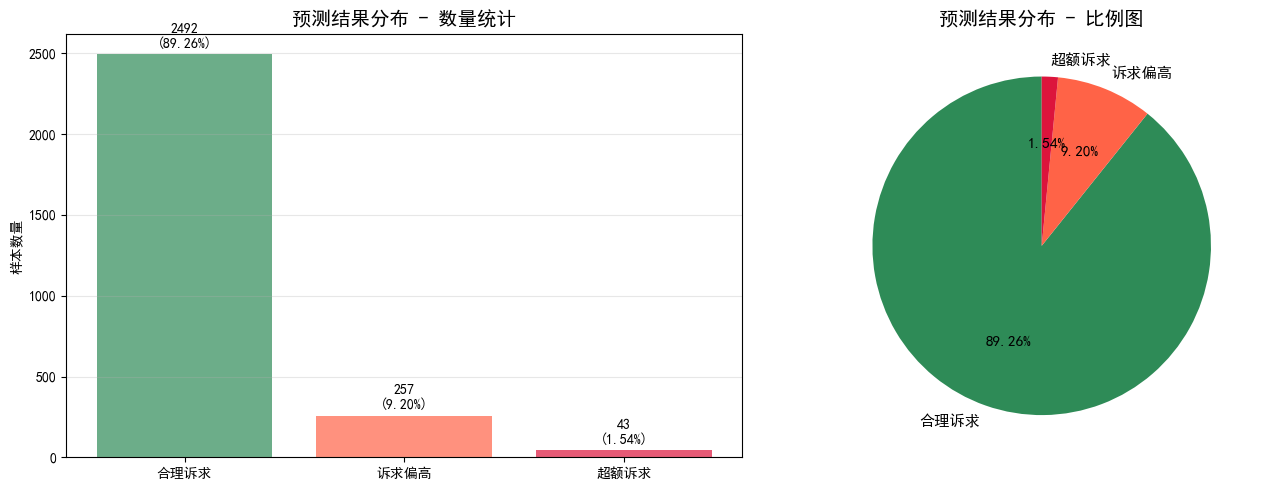


各类别平均预测概率：
  合理诉求    : 0.8241
  诉求偏高    : 0.1425
  超额诉求    : 0.0334



In [38]:
# 8) 预测结果分布统计
print('\n' + '='*60)
print('预测结果分布统计')
print('='*60)

# 统计各类别的数量和比例
dist = out_df['pred_label'].value_counts().sort_index()
total = len(out_df)

print('\n各类别预测数量与比例：')
for label in ['合理诉求', '诉求偏高', '超额诉求']:
    count = dist.get(label, 0)
    pct = (count / total) * 100
    print(f'  {label:8s}: {count:5d} 样本 ({pct:6.2f}%)')

print(f'\n总计: {total} 样本')

# 可视化预测结果分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 柱状图
labels = ['合理诉求', '诉求偏高', '超额诉求']
colors = ['#2E8B57', '#FF6347', '#DC143C']
counts = [dist.get(label, 0) for label in labels]

axes[0].bar(labels, counts, color=colors, alpha=0.7)
axes[0].set_title('预测结果分布 - 数量统计', fontsize=14, fontweight='bold')
axes[0].set_ylabel('样本数量')
axes[0].grid(axis='y', alpha=0.3)

# 添加数值标签
for i, (label, count) in enumerate(zip(labels, counts)):
    axes[0].text(i, count + total*0.01, f'{count}\n({count/total*100:.2f}%)', 
                 ha='center', va='bottom', fontweight='bold')

# 饼图
axes[1].pie(counts, labels=labels, autopct='%1.2f%%', startangle=90, colors=colors, 
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('预测结果分布 - 比例图', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 概率分布统计
print('\n各类别平均预测概率：')
for i, label in enumerate(['合理诉求', '诉求偏高', '超额诉求']):
    prob_col = f'prob_{label}'
    avg_prob = out_df[prob_col].mean()
    print(f'  {label:8s}: {avg_prob:.4f}')

print('\n' + '='*60)